# Objectives

- Data preparation: cleaning, transforming and augmentation
- Data analysis: drawing insight, creating visualizations
- Model development: creating simple as well as complex prediction models
- Model refinement: found the optimum model using Grid Search

---
## Senario
You have been employed as a Data Scientist by a consultancy firm. The firm has a client who is a used car dealer. They have a special feature on Ford cars and they want your firm to design a model that can predict the optimum quotation price for the cars in their lot. They provide you with sales data for the past few years. The dataset contains different features of the cars and the price they were sold at.

The tasks assigned to you are as follows.
1. There might be a few duplicate entries and a few missing values in the dataset. Data cleaning will be a part of the assignment.
2. You have to perform exploratory data analysis to draw keen insights on the data and determine the effect of different features on the price. Some specific requests by the client include:\
    a. Identify number of sales for each fuel type\
    b. Identify which transmission type has more price outliers
3. Compare the models with linear, polynomial and ridge regressions on single and multiple variables to find the best performing model
4. Perform a Grid Search on the Ridge regression model to identify the optimum hyperparameter for the model for best performance.

### About the Dataset: Used Ford Car Sale Prices

This dataset contains used car sale prices for Ford vehicles. It originates from the **Ford Car Pricing Dataset** publicly available on Kaggle, released under the **CC0: Public Domain** license. The dataset has been slightly modified for the purposes of this specific project.

#### Attribute Descriptions

The variables (columns) in the dataset are described in the following table:

| Variable | Description |
| :--- | :--- |
| **model** | The name/model of the car. |
| **year** | The manufacturing year of the car. |
| **transmission** | The type of transmission (Automatic, Manual, or Semi-Auto). |
| **mileage** | The number of miles the car has traveled. |
| **fuelType** | The type of fuel used by the car (Petrol, Diesel, Hybrid, Electric, or Other). |
| **tax** | The annual tax payable for the car, measured in USD. |
| **mpg** | The fuel efficiency of the car, measured in Miles per Gallon. |
| **engineSize** | The size of the car's engine. |
| **price** | The sale price of the car, measured in USD. |

---

# Install required libraries

In [1]:
%pip install seaborn
import piplite

await piplite.install(['nbformat', 'plotly'])

# Dataset URL from the GenAI lab

In [2]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"

In [3]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = URL

await download(path, "car_data.csv")
file_name  = "car_data.csv"

# Importing the Dataset

Prompt instruction:
```text
Generate plain basic python code without using condition or exceptions or if else statements. Response should be concise.
```

Prompt:

```text
Write a Python code that can perform the following tasks.
1. Read the CSV file, located on a given file path, into a pandas data frame, assuming that the first row of the file can be used as the headers for the data.
2. Print the first 5 rows of the dataframe to verify correct loading.
```

In [5]:
import pandas as pd

data_path = "car_data.csv"
df = pd.read_csv(data_path)

print(df.head(5))

     model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0   Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1    Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2    Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3   Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4   Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   

   price  
0  12000  
1  14000  
2  13000  
3  17500  
4  16500  


# Data Preparation
## Data Cleaning
At this stage, it is required to clean up the data. As has been informed to you, the data may have missing values and duplicate entries. Write a prompt that performs the following tasks

1. Identifies the columns with missing values and fills the blank cells with average value of the columns.
2. Identifies and drops the duplicate entries from the data.

Prompt:

```text
Write a Python code that performs the following tasks:
1. Identify the columns of a data frame with missing values.
2. Replace the missing values thus identified with mean value of the column.
3. Deletes the duplicate entries from the data frame.
```

In [7]:
# 1) Identify columns with missing values
missing_cols = df.columns[df.isnull().any()] 
print(list(missing_cols))

# 2) Replace missing values with the column mean (numeric columns only)
df = df.fillna(df.mean(numeric_only=True))

# 3) Delete duplicate rows
df = df.drop_duplicates()

['tax']


In [8]:
df.head(5)

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,Fiesta,2017,Automatic,15944,Petrol,150.0,57.7,1.0,12000
1,Focus,2018,Manual,9083,Petrol,150.0,57.7,1.0,14000
2,Focus,2017,Manual,12456,Petrol,150.0,57.7,1.0,13000
3,Fiesta,2019,Manual,10460,Petrol,145.0,40.3,1.5,17500
4,Fiesta,2019,Automatic,1482,Petrol,145.0,48.7,1.0,16500


## Data Augmentation

bla bla bla

# Data Insights and Visualization

## 1. Identify the 5 attributes that have the highest correlation with the `price` parameter.

Prompt:
```text
Write a Python code that identifies the top 5 attributes with highest correlation with the target attribute in a data frame.
```

In [13]:
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_price = df[numeric_cols].corrwith(df['price']).abs() 
top5 = corr_with_price.drop(labels=['price'], errors='ignore').sort_values(ascending=False).head(5)

print(top5)

year          0.635715
mileage       0.530483
engineSize    0.411451
tax           0.405970
mpg           0.346263
dtype: float64


## 2. Count the number of cars under each unique value of `fuelType` attribute.

Prompt:
```text
Write a Python code that counts the number of entries in a dataframe with each unique value of a specific attribute.
```

In [16]:
counts = df['fuelType'].value_counts(dropna=False) 
print(counts)

fuelType
Petrol      12081
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64


## 3. Create a Box plot to determine whether cars with automatic, manual or semi-auto type of `transmission` have more price outliers. Use the Seaborn library for creating the plot.

Prompt:
```text
Write a Python code that creates a Seaborn box plot between a source and target attributes of a dataframe.
```

<ipython-input-17-a28dbbf3ac6d>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='transmission', y='price', data=df, palette='Set2')


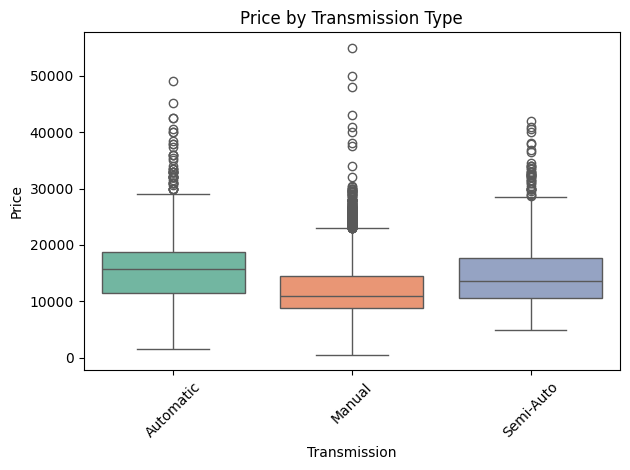

In [17]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.boxplot(x='transmission', y='price', data=df, palette='Set2') 
plt.title('Price by Transmission Type') 
plt.xlabel('Transmission') 
plt.ylabel('Price') 
plt.xticks(rotation=45) 
plt.tight_layout() 
plt.show()

## 4. Generate the regression plot between `mpg` parameter and the `price` to determine the correlation type between the two.

Prompt:
```text
Write a Python code that creates a regression plot between a source attribute and a target attribute.
```

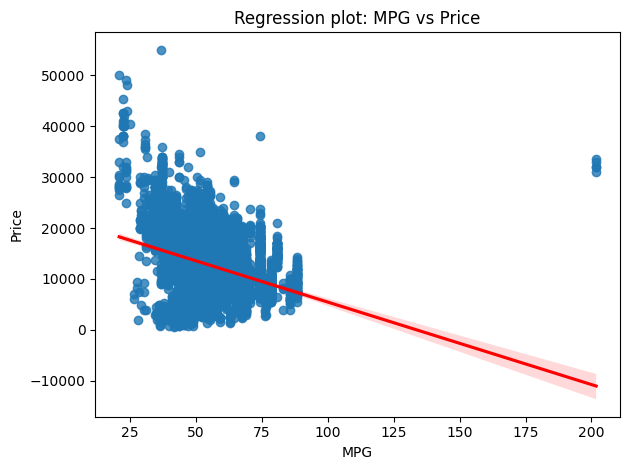

In [19]:
sns.regplot(x='mpg', y='price', data=df, line_kws={'color': 'red'}) 
plt.title('Regression plot: MPG vs Price') 
plt.xlabel('MPG') 
plt.ylabel('Price') 
plt.tight_layout() 
plt.show()

# Model Development and Evaluation

### 1. Fit a linear regression model to predict the `price` using the feature `mpg`. Then calculate the R^2 and MSE values for the model.

Prompt:
```text
Write a Python code to fit a linear regression model on a target variable on basis of a source variable. Calculate the R^2 values and MSE values for this model.
```

In [22]:
import pandas as pd 
import numpy as np 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error

# assume df has columns 'mpg' and 'price'
X = df[['mpg']].values 
y = df['price'].values

model = LinearRegression() 
model.fit(X, y)

y_pred = model.predict(X)

r2 = model.score(X, y) 
mse = mean_squared_error(y, y_pred)

print("R^2:", r2) 
print("MSE:", mse)

R^2: 0.1198980224962416
MSE: 19741690.809446193


### 2. Fit a linear regression model to predict the `price` using the following set of features.
`year`, `mileage`, `tax`, `mpg` and `engineSize`.
Calculate the R^2 and MSE values for this model.

Prompt:
```text
Write a Python code to fit a linear regression model on a target variable on basis of a set of source variables. Calculate the R^2 values and MSE values for this model.
```

In [23]:
# assume df contains 'year', 'mileage', 'tax', 'mpg', 'engineSize', and 'price'
feature_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize'] 
X = df[feature_cols].values 
y = df['price'].values

model = LinearRegression() 
model.fit(X, y)

y_pred = model.predict(X) 
r2 = model.score(X, y) 
mse = mean_squared_error(y, y_pred)

print("R^2:", r2) 
print("MSE:", mse)

R^2: 0.7265379654547005
MSE: 6134065.224381731


### 3. For the same set of features as in the question above, create a pipeline model object that uses standard scalar, second degree polynomial features and a linear regression model. Calculate the R^2 value and the MSE value for this model.

Prompt:
```text
Write a Python code that can perform the following tasks.

1. Create a pipeline with standard scalar, second degree polynomial features and linear regression model.
2. Fit this pipeline for a target variable using a set of source attributes from a dataframe.
3. Evaluate the R^2 and MSE values for the trained model.
```

In [24]:
import pandas as pd 
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler, PolynomialFeatures 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error

# features and target
feature_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize'] 
X = df[feature_cols] 
y = df['price']

# pipeline: scale -> polynomial features (degree 2) -> linear regression
pipe = Pipeline([ 
    ('scaler', StandardScaler()), 
    ('poly', PolynomialFeatures(degree=2, include_bias=False)), 
    ('model', LinearRegression()) 
])

# fit and evaluate
pipe.fit(X, y) 
y_pred = pipe.predict(X)

r2 = pipe.score(X, y)
mse = mean_squared_error(y, y_pred)

print("R^2:", r2) 
print("MSE:", mse)

R^2: 0.7666619695239302
MSE: 5234038.065462741


### 4. For the same set of features, split the data into training and testing data parts. Assume testing part to be 20%. Create and fit a Ridge regression object using the training data, set the regularization parameter to 0.1, and calculate the R^2 using the test data.

Prompt:
```text
Write a Python code that can perform the following tasks.

1. Assuming that a subset of the attributes of a data frame are source attributes and one of the attributes is a target attribute, split the data into training and testing data assuming the testing data to be 20%.
2. Create and fit a Ridge regression model using the training data, setting the regularization parameter to 0.1.
3. Calculate the MSE and R^2 values for the Ridge Regression model using the testing data.
```

In [25]:
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import Ridge 
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
X = df.drop('price', axis=1) 
y = df['price']

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Split into train/test (20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ridge regression with alpha = 0.1
model = Ridge(alpha=0.1) 
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred)

print("MSE:", mse) 
print("R2:", r2)

MSE: 4059414.8914707717
R2: 0.8189624368445106


### 5. Perform a second order polynomial transform on both the training data and testing data created for the question above. Create and fit a Ridge regression object using the modified training data, set the regularisation parameter to 0.1, and calculate the R^2 and MSE utilising the modified test data.

Prompt:
```text
Write a Python code that can perform the following tasks.

1. Assuming that a subset of the attributes of a data frame are source attributes and one of the attributes is a target attribute, split the data into training and testing data assuming the testing data to be 20%.
2. Apply second degree polynomial scaling to the training and testing data.
3. Create and fit a Ridge regression model using the training data, setting the regularization parameter to 0.1.
4. Calculate the MSE and R^2 values for the Ridge Regression model using the testing data.
```

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
X = df.drop('price', axis=1)
y = df['price']

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Split into train/test (20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Ridge regression with alpha = 0.1
model = Ridge(alpha=0.1)
model.fit(X_train_poly, y_train)

# Predict on test set
y_pred = model.predict(X_test_poly)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.7948e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


MSE: 3175556.538530818
R2: 0.8583798323728844


### 6. In the question above, perform a Grid Search on ridge regression for a set of values of alpha {0.01, 0.1, 1, 10, 100} with 4-fold cross validation to find the optimum value of alpha to be used for the prediction model.

Prompt:
```text
Write a Python code that can perform the following tasks.

1. Assuming that a subset of the attributes of a data frame are source attributes and one of the attributes is a target attribute, split the data into training and testing data assuming the testing data to be 20%.
2. Apply second degree polynomial scaling to the training and testing data.
3. Create and fit a Grid search on Ridge regression with cross validation using the training data, for a set of values of the parameter alpha.
4. Calculate the MSE and R^2 values for the Ridge Regression model using the testing data.
```

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score


# Features and target
X = df.drop('price', axis=1)
y = df['price']

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Split into train/test (20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline: polynomial features degree 2 + standard scaling + ridge regression
pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Grid search over alpha values with 4-fold cross-validation
param_grid = {
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}
grid = GridSearchCV(
    estimator=pipe, 
    param_grid=param_grid, 
    cv=4, 
    scoring='neg_mean_squared_error'
)

# Fit on training data
grid.fit(X_train, y_train)

# Best model and predictions on test data
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)